# Scatter Plot with Mixed Data

In this notebook, I will use a blend of college production and combine production to try and find a correlation of where receivers are drafted.
<br><br>
I'll start by running the query I did in the last notebook.
***

In [4]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('nfl_analytics.db')

query = """
WITH player_data AS (
    SELECT 
        c.Player,
        c.Conf,
        AVG(c.RecYperG) as college_ypg,
        AVG(c.YperR) as yards_per_catch,
        MAX(c.RecTD) as peak_td,
        com.`40yd` as forty_time,
        d.Player AS Pick,
        d.Year as draft_year,
        CASE 
            WHEN c.Conf IN ('SEC', 'Big Ten') THEN 'SEC, BIG 10'
            WHEN c.Conf IN ('ACC', 'Big 12', 'Pac-12') THEN 'ACC, BIG 12, PAC 12'
            ELSE 'Other'
        END as conference_tier
    FROM college c
    LEFT JOIN draft_picks d ON d.Name = c.Player
    LEFT JOIN combine com ON com.Player = c.Player
    WHERE d.Year BETWEEN 2017 AND 2025
        AND com.`40yd` IS NOT NULL  -- Only players with 40 time
        AND com.`40yd` > 0
    GROUP BY c.Player
)
SELECT * FROM player_data
ORDER BY Pick;
"""



# Execute and display
player_data = pd.read_sql_query(query, conn)

print("WR COLLEGE STATS AND PICKS (2017-2025)")
print("=" * 100)
print(player_data.to_string(index=False))


conn.close()

WR COLLEGE STATS AND PICKS (2017-2025)
                  Player     Conf  college_ypg  yards_per_catch  peak_td  forty_time  Pick  draft_year     conference_tier
           Ja'Marr Chase      SEC   127.100000        21.200000       20        4.34     5        2021         SEC, BIG 10
             Rome Odunze   Pac-12    83.600000        14.400000       13        4.45     9        2024 ACC, BIG 12, PAC 12
          Garrett Wilson  Big Ten    72.500000        15.433333       12        4.38    10        2022         SEC, BIG 10
             Chris Olave  Big Ten    80.900000        15.433333       13        4.39    11        2022         SEC, BIG 10
             Jerry Jeudy      SEC    88.600000        17.200000       14        4.45    15        2020         SEC, BIG 10
            Jahan Dotson  Big Ten    78.066667        16.033333       12        4.43    16        2022         SEC, BIG 10
             CeeDee Lamb   Big 12    80.800000        18.900000       14        4.50    17        20

### Scatter Plot
Now we need to plot it on a scatter plot to see what we can find! For this run, I am going to plot college yardage on the x axis, 40 yard dash time on the y axis, and I will plot the draft position by the size of each point. I will also make the color of each point different depending on how notable of a conference they are in.

#### LEGEND
| X AXIS | Y AXIS | Point Size | Point Color | 
| :--- | :--- | :--- | :--- |
| College YPG | 40 Yard Dash | Draft Position <br> BIG = Top 10 <br> SMALL = Late Round | Conference <br>RED = SEC, BIG 10<br> BLUE = ACC, BIG 12, PAC 12<br>GREEN = Other |

CREATING SCATTER PLOT: COLLEGE PRODUCTION vs 40 TIME
Total players with data: 167
Pick range: 5 to 258



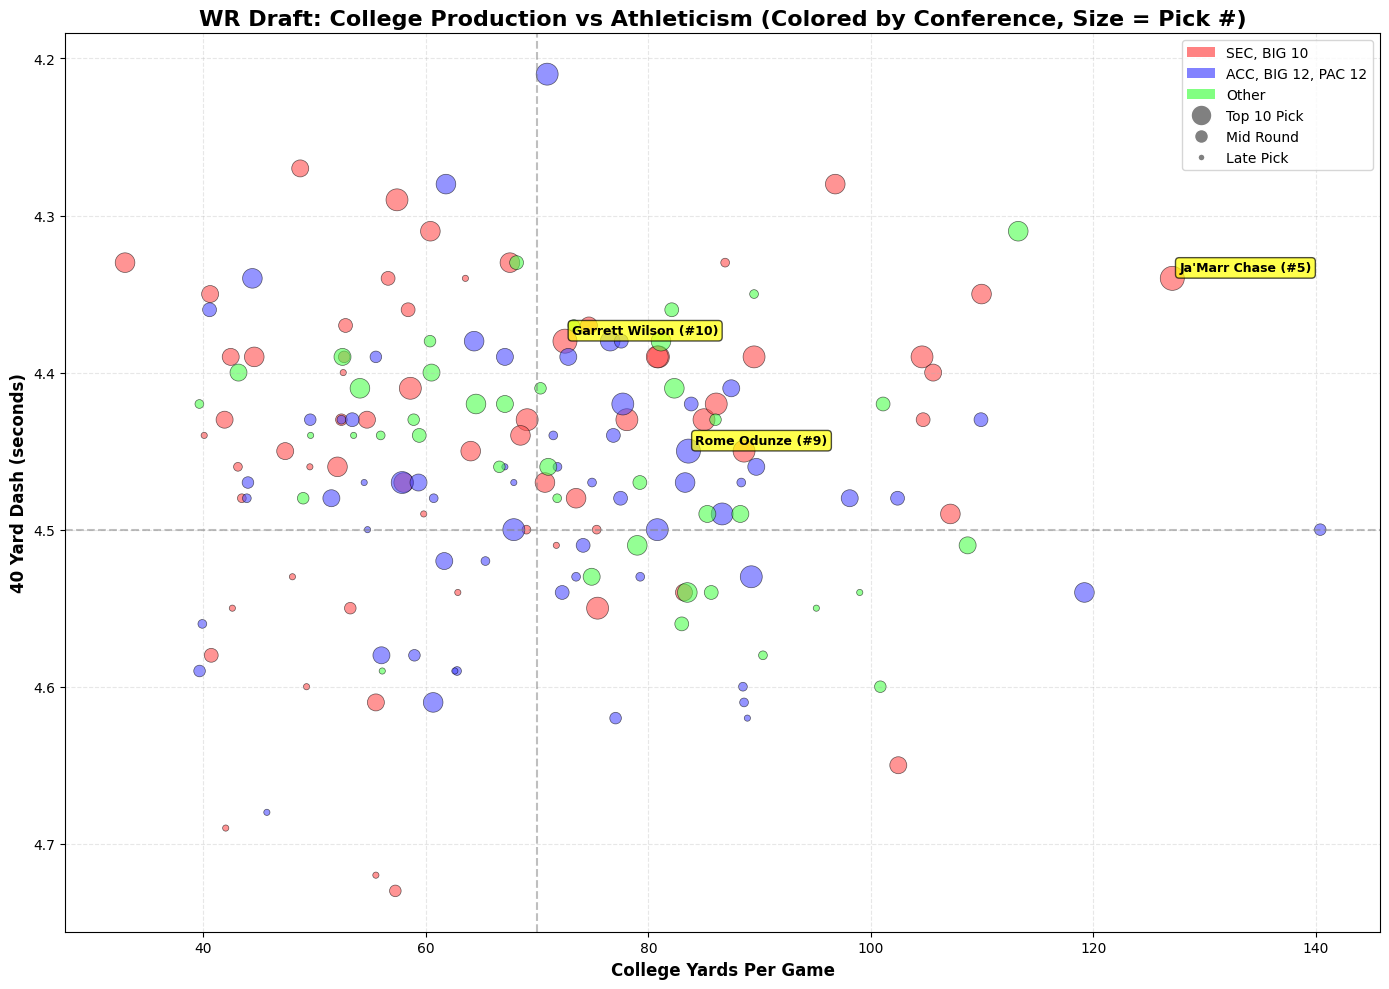


SUMMARY BY CONFERENCE TIER:
                     Count  Avg YPG  Avg 40 Time  Avg Pick
conference_tier                                           
ACC, BIG 12, PAC 12     62    71.05         4.48    128.21
Other                   41    73.99         4.45    134.37
SEC, BIG 10             64    66.27         4.45    106.92

Visualization saved as 'wr_draft_scatter_by_pick.png'


In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_marker_size(pick):
    # BASED ON ROUNDS LAST YEAR
    if pick <= 10:
        return 300  # Top 10: huge
    elif pick <= 32:
        return 250  # Round 1: big
    elif pick <= 64:
        return 200  # Round 2: medium-large
    elif pick <= 102:
        return 150  # Round 3: medium
    elif pick <= 138:
        return 100   # Round 4: small
    elif pick <= 176:
        return 70   # Round 5: small
    elif pick <= 216:
        return 40   # Round 6: small
    else:
        return 20   # Round 7: tiny


print("CREATING SCATTER PLOT: COLLEGE PRODUCTION vs 40 TIME")
print("=" * 60)

# first, let's check what's in player_data
print(f"Total players with data: {len(player_data)}")
print(f"Pick range: {player_data['Pick'].min()} to {player_data['Pick'].max()}")
print("\n" + "=" * 60)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 10))

# define colors for conference tiers
conference_colors = {
    'SEC, BIG 10': '#FF4D4D',         # Red
    'ACC, BIG 12, PAC 12': '#4D4DFF', # Blue
    'Other': '#4DFF4D'                # Green
}

# Define marker sizes based on pick number (lower pick = bigger marker)
max_pick = player_data['Pick'].max()
player_data['marker_size'] = player_data['Pick'].apply(get_marker_size)

# create scatter plot for each conference tier
for tier, color in conference_colors.items():
    tier_data = player_data[player_data['conference_tier'] == tier]
    
    if len(tier_data) > 0:
        scatter = ax.scatter(
            tier_data['college_ypg'], 
            tier_data['forty_time'],
            s=tier_data['marker_size'],  # Size by pick number
            c=color,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5,
            label=f"{tier} ({len(tier_data)} players)"
        )

# add labels for top 10 picks
top_picks = player_data[player_data['Pick'] <= 10]
for _, player in top_picks.iterrows():
    ax.annotate(
        f"{player['Player']} (#{player['Pick']})",
        (player['college_ypg'], player['forty_time']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
    )

# add a colorbar to explain marker sizes
# create a legend for pick ranges
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF4D4D', alpha=0.7, label='SEC, BIG 10'),
    Patch(facecolor='#4D4DFF', alpha=0.7, label='ACC, BIG 12, PAC 12'),
    Patch(facecolor='#4DFF4D', alpha=0.7, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='Top 10 Pick'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='Mid Round'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='Late Pick')
]

# customize the chart
ax.set_xlabel('College Yards Per Game', fontsize=12, fontweight='bold')
ax.set_ylabel('40 Yard Dash (seconds)', fontsize=12, fontweight='bold')
ax.set_title('WR Draft: College Production vs Athleticism (Colored by Conference, Size = Pick #)', 
             fontsize=16, fontweight='bold')

# invert y-axis (lower 40 time is better)
ax.invert_yaxis()

# add grid
ax.grid(True, alpha=0.3, linestyle='--')

# add legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# add some reference lines (optional)
ax.axhline(y=4.5, color='gray', linestyle='--', alpha=0.5, label='4.5 sec threshold')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='70 YPG threshold')

plt.tight_layout()
plt.savefig('wr_draft_scatter_by_pick.png', dpi=300, bbox_inches='tight')
plt.show()

# show summary statistics
print("\nSUMMARY BY CONFERENCE TIER:")
print("=" * 60)
summary = player_data.groupby('conference_tier').agg({
    'Player': 'count',
    'college_ypg': 'mean',
    'forty_time': 'mean',
    'Pick': 'mean'
}).round(2)
summary.columns = ['Count', 'Avg YPG', 'Avg 40 Time', 'Avg Pick']
print(summary.to_string())

print("\nVisualization saved as 'wr_draft_scatter_by_pick.png'")

***
#### Unclear findings 
This visualization I find to be a little unclear. I think it would be more beneficial if I were to swap a few things. I think it would show us more if I made the Y-Axis be draft position and point size to be based on 40 time. So I will make those changes! Here is the new legend:

#### LEGEND
| X AXIS | Y AXIS | Point Size | Point Color | 
| :--- | :--- | :--- | :--- |
| College YPG | Draft Position | 40 Yard Dash <br> BIG = Sub 4.3 sec <br> SMALL = Greater than 4.7 sec | Conference <br>RED = SEC, BIG 10<br> BLUE = ACC, BIG 12, PAC 12<br>GREEN = Other |

CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION
Total players with data: 167
Pick range: 5 to 258



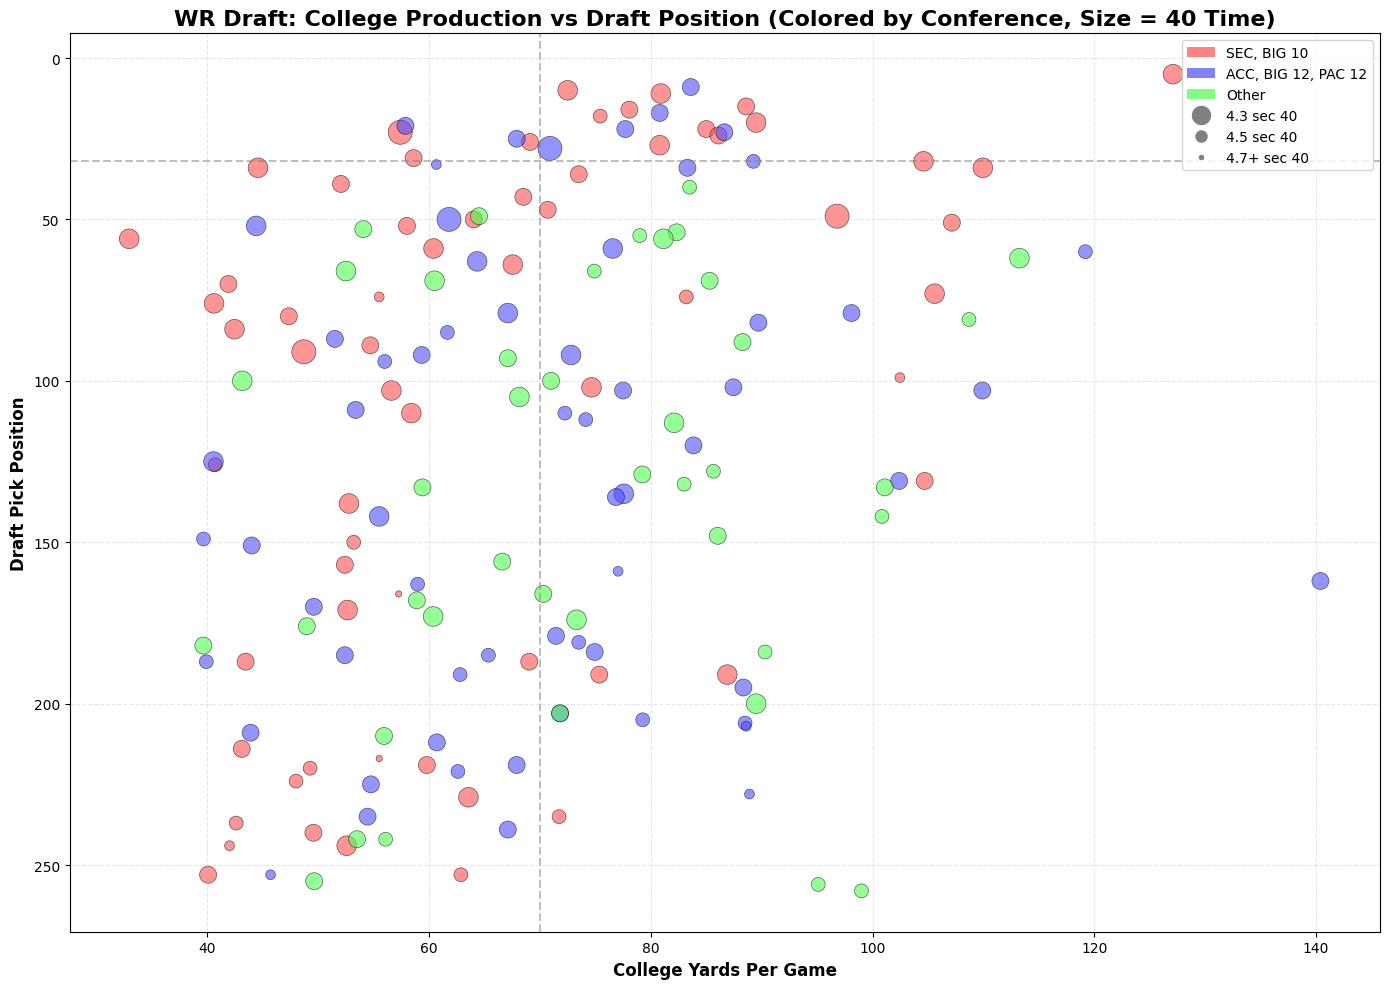


SUMMARY BY CONFERENCE TIER:
                     Count  Avg YPG  Avg 40 Time  Avg Pick
conference_tier                                           
ACC, BIG 12, PAC 12     62    71.05         4.48    128.21
Other                   41    73.99         4.45    134.37
SEC, BIG 10             64    66.27         4.45    106.92

Visualization saved as 'wr_draft_scatter_by_pick.png'


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def get_marker_size(dash):
    # BASED ON ROUNDS LAST YEAR
    if dash <= 4.3:
        return 300  # Top 10: huge
    elif dash <= 4.4:
        return 200  # Round 1: big
    elif dash <= 4.5:
        return 150  # Round 2: medium-large
    elif dash <= 4.6:
        return 100  # Round 3: medium
    elif dash <= 4.7:
        return 50   # Round 4: small
    elif dash <= 4.8:
        return 20   # Round 5: small
    elif dash <= 4.9:
        return 10   # Round 6: small
    else:
        return 5   # Round 7: tiny


print("CREATING SCATTER PLOT: COLLEGE PRODUCTION vs DRAFT POSITION")
print("=" * 60)

# first, let's check what's in player_data
print(f"Total players with data: {len(player_data)}")
print(f"Pick range: {player_data['Pick'].min()} to {player_data['Pick'].max()}")
print("\n" + "=" * 60)

# set up the plot
fig, ax = plt.subplots(figsize=(14, 10))

# define colors for conference tiers
conference_colors = {
    'SEC, BIG 10': '#FF4D4D',         # Red
    'ACC, BIG 12, PAC 12': '#4D4DFF', # Blue
    'Other': '#4DFF4D'                # Green
}

# define marker sizes based on 40 time (lower 40 time = bigger marker)
max_pick = player_data['forty_time'].max()
player_data['marker_size'] = player_data['forty_time'].apply(get_marker_size)

# create scatter plot for each conference tier
for tier, color in conference_colors.items():
    tier_data = player_data[player_data['conference_tier'] == tier]
    
    if len(tier_data) > 0:
        scatter = ax.scatter(
            tier_data['college_ypg'], 
            tier_data['Pick'],
            s=tier_data['marker_size'],  # Size by pick number
            c=color,
            alpha=0.6,
            edgecolors='black',
            linewidth=0.5,
            label=f"{tier} ({len(tier_data)} players)"
        )

# add labels for top 10 picks
#top_picks = player_data[player_data['Pick'] <= 10]
#for _, player in top_picks.iterrows():
#    ax.annotate(
#        f"{player['Player']} (#{player['Pick']})",
#        (player['college_ypg'], player['forty_time']),
#        xytext=(5, 5),
#        textcoords='offset points',
#        fontsize=9,
#        fontweight='bold',
#        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7)
#    )

# add a colorbar to explain marker sizes
# create a legend for pick ranges
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Patch(facecolor='#FF4D4D', alpha=0.7, label='SEC, BIG 10'),
    Patch(facecolor='#4D4DFF', alpha=0.7, label='ACC, BIG 12, PAC 12'),
    Patch(facecolor='#4DFF4D', alpha=0.7, label='Other'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=15, label='4.3 sec 40'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='4.5 sec 40'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=5, label='4.7+ sec 40')
]

# customize the chart
ax.set_xlabel('College Yards Per Game', fontsize=12, fontweight='bold')
ax.set_ylabel('Draft Pick Position', fontsize=12, fontweight='bold')
ax.set_title('WR Draft: College Production vs Draft Position (Colored by Conference, Size = 40 Time)', 
             fontsize=16, fontweight='bold')

# invert y-axis (lower 40 time is better)
ax.invert_yaxis()

# add grid
ax.grid(True, alpha=0.3, linestyle='--')

# add legend
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# add some reference lines (optional)
ax.axhline(y=32, color='gray', linestyle='--', alpha=0.5, label='End of Round 1')
ax.axvline(x=70, color='gray', linestyle='--', alpha=0.5, label='70 YPG threshold')

plt.tight_layout()
plt.savefig('wr_draft_scatter_by_pick.png', dpi=300, bbox_inches='tight')
plt.show()

# show summary statistics
print("\nSUMMARY BY CONFERENCE TIER:")
print("=" * 60)
summary = player_data.groupby('conference_tier').agg({
    'Player': 'count',
    'college_ypg': 'mean',
    'forty_time': 'mean',
    'Pick': 'mean'
}).round(2)
summary.columns = ['Count', 'Avg YPG', 'Avg 40 Time', 'Avg Pick']
print(summary.to_string())

print("\nVisualization saved as 'wr_draft_scatter_by_pick.png'")

***
## STILL NEEDS WORK
There hasn't been any significant findings in this notebook yet, so we will need to continue to work to try and find something significant!

***
## LINKS <br>
#### [PORTFOLIO](https://quinng8.github.io/nfl-draft-analytics/)
#### [Predictive NFL Success](https://quinng8.github.io/nfl-draft-analytics/04_predictive_NFL_success.html)